In [43]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from scipy.special import expit  # sigmoid
import seaborn as sns

In [44]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and target
y_raw = df['Attrition'].values
X = df.drop(columns=['Attrition']).values
y = (y_raw == y_raw.max()).astype(int)
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Original class distribution (real data):")
print(f"  No Attrition (0): {np.sum(y == 0)}")
print(f"  Attrition    (1): {np.sum(y == 1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Test class distribution (real, untouched):")
print(f"  No Attrition (0): {np.sum(y_test == 0)}")
print(f"  Attrition    (1): {np.sum(y_test == 1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train.shape[0]} samples")
print(f"  No Attrition (0): {np.sum(y_train == 0)}")
print(f"  Attrition    (1): {np.sum(y_train_resampled == 1)}")

Dataset shape: (1470, 37)

Features shape: (1470, 36)
Original class distribution (real data):
  No Attrition (0): 1232
  Attrition    (1): 238

Train: 1176 samples | Test: 294 samples
Test class distribution (real, untouched):
  No Attrition (0): 246
  Attrition    (1): 48

After SMOTE — Train: 1176 samples
  No Attrition (0): 986
  Attrition    (1): 986


In [45]:
import numpy as np

class MyPCA:
    def __init__(self, variance_ratio=0.95):
        self.variance_ratio = variance_ratio
        
    def fit(self, X):
        # 1️⃣ Center data
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # 2️⃣ Covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # 3️⃣ Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
        
        # 4️⃣ Sort eigenvalues (descending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        
        # 5️⃣ Compute explained variance ratio
        total_variance = np.sum(eigenvalues)
        explained_variance_ratio = eigenvalues / total_variance
        
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        # เลือกจำนวน component ที่ได้ ≥ 95%
        n_components = np.argmax(cumulative_variance >= self.variance_ratio) + 1
        
        self.n_components_ = n_components
        self.components_ = eigenvectors[:, :n_components]
        self.explained_variance_ratio_ = explained_variance_ratio[:n_components]
        
        return self
    
    def transform(self, X):
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


===== SKLEARN PCA =====
Original feature count: 36
Reduced feature count: 28
Total variance kept: 0.9529176097448907
ROC-AUC (Sklearn PCA): 0.7547425474254742
Classification report for library SVM (threshold=0.15):
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       246
           1       0.38      0.56      0.45        48

    accuracy                           0.78       294
   macro avg       0.64      0.69      0.66       294
weighted avg       0.82      0.78      0.79       294

accuracy for library SVM (threshold=0.15): 0.7789115646258503
specificity for library SVM (threshold=0.15): 0.8211382113821138


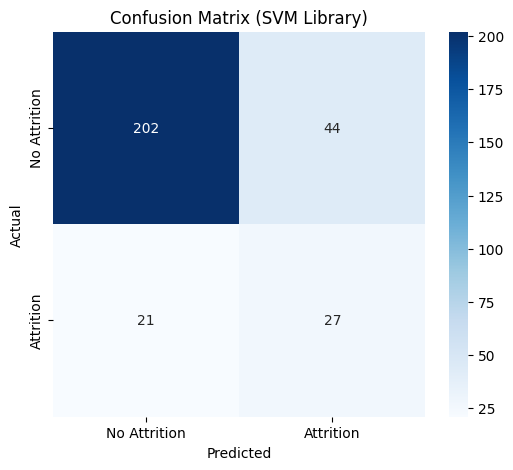

In [52]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

# -------------------------
# PCA (Library)
# -------------------------

pca_lib = PCA(n_components=0.95, random_state=42)

X_train_pca_lib = pca_lib.fit_transform(X_train_resampled)
X_test_pca_lib = pca_lib.transform(X_test)

print("\n===== SKLEARN PCA =====")

print("Original feature count:", X_train_resampled.shape[1])
print("Reduced feature count:", X_train_pca_lib.shape[1])
print("Total variance kept:", sum(pca_lib.explained_variance_ratio_))

# -------------------------
# Train SVM
# -------------------------

svm_lib = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_lib.fit(X_train_pca_lib, y_train_resampled)

# Predict

y_proba_lib = svm_lib.predict_proba(X_test_pca_lib)[:, 1]
y_pred_lib = (y_proba_lib > 0.15).astype(int)

roc_auc_lib = roc_auc_score(y_test, y_proba_lib)

print("ROC-AUC (Sklearn PCA):", roc_auc_lib)
print("Classification report for library SVM (threshold=0.15):")
print(classification_report(y_test, y_pred_lib))
print("accuracy for library SVM (threshold=0.15):", accuracy_score(y_test, y_pred_lib))
print("specificity for library SVM (threshold=0.15):", confusion_matrix(y_test, y_pred_lib)[0, 0] / np.sum(confusion_matrix(y_test, y_pred_lib)[0]))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lib),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Confusion Matrix (SVM Library)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
# -------------------------
# My PCA
# -------------------------

my_pca = MyPCA(variance_ratio=0.95)

X_train_pca_my = my_pca.fit_transform(X_train_resampled)
X_test_pca_my = my_pca.transform(X_test)

print("\n===== MY PCA =====")

print("Original feature count:", X_train_resampled.shape[1])
print("Reduced feature count:", X_train_pca_my.shape[1])
print("Total variance kept:", sum(my_pca.explained_variance_ratio_))

# -------------------------
# Train SVM
# -------------------------

svm_my = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_my.fit(X_train_pca_my, y_train_resampled)

# Predict

y_proba_my = svm_my.predict_proba(X_test_pca_my)[:, 1]
y_pred_my = (y_proba_my > 0.15).astype(int)

roc_auc_my = roc_auc_score(y_test, y_proba_my)

print("ROC-AUC (My PCA):", roc_auc_my)
print("classification report for My PCA SVM:")
print(classification_report(y_test, y_pred_my))
print("accuracy for My PCA SVM:", accuracy_score(y_test, y_pred_my))
print("specificity for My PCA SVM:", confusion_matrix(y_test, y_pred_my)[0, 0] / np.sum(confusion_matrix(y_test, y_pred_my)[0]))


===== MY PCA =====
Original feature count: 36
Reduced feature count: 28
Total variance kept: 0.9529176097448907
ROC-AUC (My PCA): 0.7547425474254742
classification report for My PCA SVM:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       246
           1       0.38      0.56      0.45        48

    accuracy                           0.78       294
   macro avg       0.64      0.69      0.66       294
weighted avg       0.82      0.78      0.79       294

accuracy for My PCA SVM: 0.7789115646258503
specificity for My PCA SVM: 0.8211382113821138


In [48]:
print("\n==============================")
print("ROC-AUC Comparison")
print("==============================")

print("Sklearn PCA ROC-AUC :", roc_auc_lib)
print("My PCA ROC-AUC      :", roc_auc_my)


ROC-AUC Comparison
Sklearn PCA ROC-AUC : 0.7547425474254742
My PCA ROC-AUC      : 0.7547425474254742


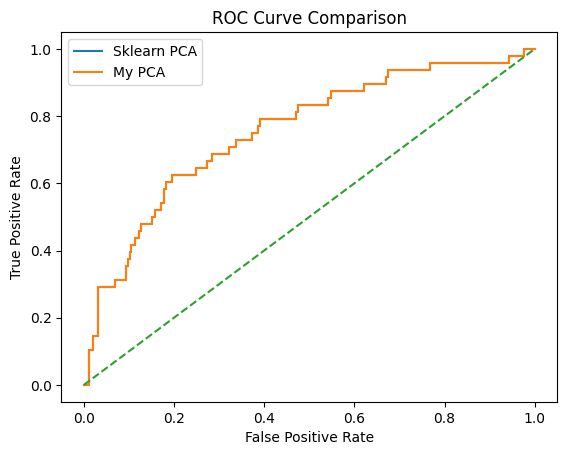

In [49]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_lib, tpr_lib, _ = roc_curve(y_test, y_proba_lib)
fpr_my, tpr_my, _ = roc_curve(y_test, y_proba_my)

plt.figure()

plt.plot(fpr_lib, tpr_lib, label="Sklearn PCA")
plt.plot(fpr_my, tpr_my, label="My PCA")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [50]:
# risk_level = []

# for p in y_proba:
#     if p < 0.15:
#         risk_level.append("Low Risk")
#     elif p < 0.40:
#         risk_level.append("Medium Risk")
#     else:
#         risk_level.append("High Risk")

# risk_df = pd.DataFrame({
#     "Probability": y_proba,
#     "Risk Level": risk_level
# })

# print("\nRisk Distribution:")
# print(risk_df["Risk Level"].value_counts())

# # -------------------------
# # Plot Risk Distribution
# # -------------------------
# risk_df["Risk Level"].value_counts().plot(kind='bar')
# plt.title("Employee Attrition Risk Distribution")
# plt.xlabel("Risk Level")
# plt.ylabel("Number of Employees")
# plt.show()